In [1]:
from glow.io import Sound

In [ ]:
from glow import _ic, ic, timer
import numpy as np
from scipy.signal import zoom_fft

x = np.random.default_rng(1234).random((10, 11, 10, 11, 10, 11, 10), dtype='f')
# x = np.random.default_rng(1234).random((3,4), dtype='f')
# x = np.arange(12).reshape(3, 4)
print(x.size)

_ic._G2 = 0
ic(x)
_ic._G2 = 1
ic(x)

if 0:
    with timer():
        g = x.astype('f')
        for a in range(x.ndim):
            loc = tuple(
                [slice(None)] * a
                + [slice(2)]
                + [slice(None)] * (x.ndim - a - 1)
            )
            # g = np.fft.rfft(g[tuple(loc)], axis=a, norm='forward')
            g = zoom_fft(g, 2, axis=a)
            print(g.shape, g.dtype)
            g = np.concatenate([g.real[loc], g.imag[loc]], a)
            print(g.shape, g.dtype)
            # g = g.astype('f')
        # g = np.fft.fftn(x, [2] * x.ndim, norm='forward')
        # g = np.fft.fft(x, norm='forward')

    # print(*ic(x, g.real, g.imag), sep='\n')
    print(*ic(x, g), sep='\n')

with timer():
    for _ in range(10):
        _ic._get_nd_grad(x)
with timer():
    for _ in range(10):
        _ic._get_nd_grad_v2(x)

13310000


ic| 2673905349.py:10 in <module>
    x: np.ndarray((10, 11, 10, 11, 10, 11, 10), float32, x∈[0.00000000, 0.99999988], x=0.50002384±0.28868061, grad=[-1.9673e-04  6.5358e-04  1.3078e-04  2.5253e-04 -9.6250e-05 -4.5720e-05
         2.2313e-04])
ic| 2673905349.py:12 in <module>
    x: np.ndarray((10, 11, 10, 11, 10, 11, 10), float32, x∈[0.00000000, 0.99999988], x=0.50002384±0.28868061, grad=[-1.9669e-04  6.5360e-04  1.3080e-04  2.5256e-04 -9.6210e-05 -4.5830e-05
         2.2307e-04])


__main__::31 line done in 579ms
__main__::34 line done in 527ms


In [3]:
import numpy as np
from scipy.interpolate import interp1d


def spectrum(x: Sound, wsize: int = 4096, f0: float = 20, f1: float = 20_000):
    assert wsize.bit_count() == 1
    assert wsize % 2 == 0
    wstep = wsize // 2
    t = x.data.mean(1)  # X(t)

    n = len(t)
    nw = len(range(0, n, wstep))
    t = np.pad(t, [(0, (nw - 1) * wstep + wsize - n)])

    n, s = len(t), t.strides[0]
    tt = np.lib.stride_tricks.as_strided(t, (nw, wsize), (wstep * s, s))

    wnd = np.sin(np.pi * (np.arange(wsize) + 0.5) / wsize)
    tt = tt * wnd
    tf = np.fft.rfft(tt, axis=1, norm='ortho')  # X(f)

    nf = tf.shape[1]
    tf_2 = tf.real**2 + tf.imag**2  # E(f)

    frq = np.fft.rfftfreq(wsize, 1 / x.rate)
    frq2 = np.logspace(np.log10(f0), np.log10(f1), 512)
    bins = np.interp(frq2, frq, np.arange(nf))
    assert frq.shape[0] == tf.shape[1]

    # E(log f)
    t_logf = tf_2.cumsum(1)
    t_logf = interp1d(
        np.arange(nf), t_logf, axis=1, copy=False, assume_sorted=True
    )(bins)
    t_logf = np.diff(t_logf, 1, 1)

    return wstep, tf_2.mean(0), tf_2, t_logf, frq, frq2[:-1]

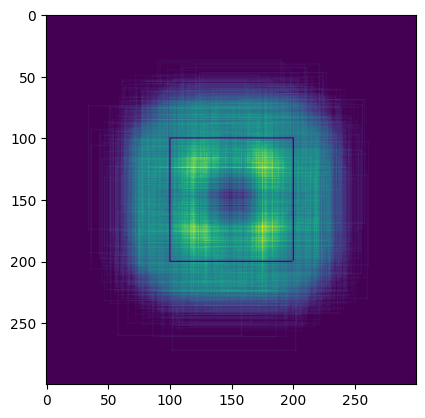

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from glow import around

rg = np.random.default_rng()
N = 100
S = 10000
FN = round(N * 3)
F0 = (FN - N) // 2
F1 = FN - F0

cnt = FN / 2
half = N / 2
im = np.zeros((FN, FN), dtype='f')
for _ in range(S):
    dyx = rg.normal(0, N / 6, size=2)
    # dyx = rg.uniform(-.5, .5, size=2) * N
    y, x = cnt_ = cnt + dyx
    box = cnt_ + [[-half], [half]]
    (y0, x0), (y1, x1) = around(box.clip(0, FN - 1)).tolist()
    k = dyx @ dyx
    im[y0 : y1 + 1, x0] += k
    im[y0 : y1 + 1, x1] += k
    im[y0, x0 : x1 + 1] += k
    im[y1, x0 : x1 + 1] += k

im[F0:F1, F0] = im[F0, F0:F1] = im[F1, F0:F1] = im[F0:F1, F1] = 1
plt.imshow(im)

In [ ]:
import numpy as np
from glow.io import Sound

rate = 44_100
pulse = (np.arange(10 * rate) % (rate // 4) == 0).astype('f')
Sound(pulse[:, None], rate).save('D:/pulse.flac')

In [ ]:
import numpy as np
from glow.io import Sound

rate = 44_100
xx = np.arange(5 * rate)  # 5s


def center(x):
    x = x.astype('f')
    lo, hi = x.min(), x.max()
    scale = 2 / (hi - lo)
    offset = (hi + lo) / 2
    return (x - offset) * scale


for f in (50, 100, 200, 500, 1000, 2000, 5000):
    phase = (xx * f) % rate
    sawtooth = center(phase.astype('f') / rate)  # [-1 .. +1]

    # [-1 .. +1]
    sine = np.sin(np.pi * sawtooth)
    triangle = 2 * np.abs(sawtooth) - 1

    rect = np.sign(sawtooth)
    (is_0,) = np.where(rect == 0)
    rect[is_0] = rect[is_0 + 1]
    rect = rect.astype('f')

    sfx = ' (0 dBFS, 0 LUFS)' if f == 1000 else ''
    Sound(sine[:, None], rate).save(f'D:/sine {f} Hz{sfx}.flac')
    Sound(triangle[:, None], rate).save(f'D:/triangle {f} Hz.flac')
    Sound(sawtooth[:, None], rate).save(f'D:/sawtooth {f} Hz.flac')
    Sound(rect[:, None], rate).save(f'D:/rect {f} Hz.flac')

In [ ]:
import math

import numpy as np
from glow.io import Sound


def rms(x: np.ndarray) -> float:
    a = np.fft.rfft(x, axis=0, norm='ortho')
    value = np.square(a.real).mean() + np.square(a.imag).mean()
    return np.sqrt(value)


def noise_psd(rand: np.ndarray, rate: int, p: int) -> np.ndarray:
    n, _ = rand.shape
    fft = np.fft.rfft(rand, axis=0, norm='ortho')

    # Gain audible freqs, mute inaudible
    k = rate / n
    lo, hi = math.ceil(20 / k), math.floor(20_000 / k)
    gain = np.linspace(0, 1, n // 2 + 1, dtype='f')
    gain[:lo] = 0
    gain[lo:hi] **= p / 2
    gain[hi:] = 0

    fft *= gain[:, None]
    x = np.fft.irfft(fft, axis=0, norm='ortho')
    x *= 0.0656 / rms(x)  # -20 LUFS @ pink

    return x.astype('f')


c = 2  # channels
t = 5  # s
rate = 192_000  # Hz
rg = np.random.default_rng(12345)


n = t * rate
rands = {
    'N': rg.standard_normal((n, c), dtype='f'),
    'U': rg.random((n, c), dtype='f') * 2 - 1,
}
for name, p in {
    'white': 0,  # same energy per freq
    'pink': -1,  # same energy per octave, ok for volume calibration
    'brownian': -2,
}.items():
    print(name)
    for rname, rand in rands.items():
        print(rname)
        q = noise_psd(rand, rate, p)

        db_rms = 20 * np.log10(rms(q))
        peak = np.abs(q).max()
        peak_dbfs = 20 * np.log10(peak)
        print(
            f'{db_rms:+6.2f} dB RMS,',
            f'{peak_dbfs:+6.2f} dBFS peak',
            f'({peak:8.6f})',
        )

        Sound(q, rate).save(f'D:/{name} noise ({rname}).flac')

white
N
-23.66 dB RMS,  -9.49 dBFS peak (0.335533)
U
-23.66 dB RMS, -10.76 dBFS peak (0.289771)
pink
N
-23.66 dB RMS, -10.09 dBFS peak (0.313069)
U
-23.66 dB RMS,  -9.90 dBFS peak (0.319926)
brownian
N
-23.66 dB RMS,  -9.69 dBFS peak (0.327802)
U
-23.66 dB RMS, -10.23 dBFS peak (0.308055)


In [ ]:
import numpy as np
from glow.io import Sound

rate = 44_100
rg = np.random.default_rng(12345)

uniform = Sound(rg.random((5 * rate, 1), dtype='f') * 2 - 1, rate)
uniform.save('D:/test uniform (0 dBFS).flac')

normal = Sound(rg.normal(size=(5 * rate, 1)).clip(-1, 1).astype('f'), rate)
normal.save('D:/test normal (0 dBFS).flac')

D:/Music/TEST_Pink noise (ID 0432)_BSB.flac
Sound(duration=0:00:19.126803, channels=2, dtype=float32) 0.998260498046875
dE/df peak: 2.1539604576412765, dE/dlog f peak: 2.053919318469582
(206, 4097)


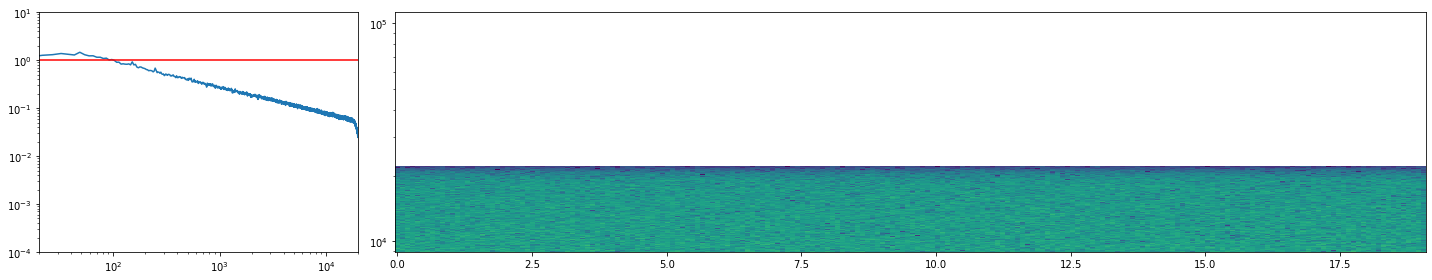

D:/Music/EBU-reference_listening_signal_pinknoise_500Hz_2kHz_R128.flac
Sound(duration=0:02:00, channels=1, dtype=float32) 0.323089599609375
dE/df peak: 0.08304095529755413, dE/dlog f peak: 0.7456170099175443
(1407, 4097)


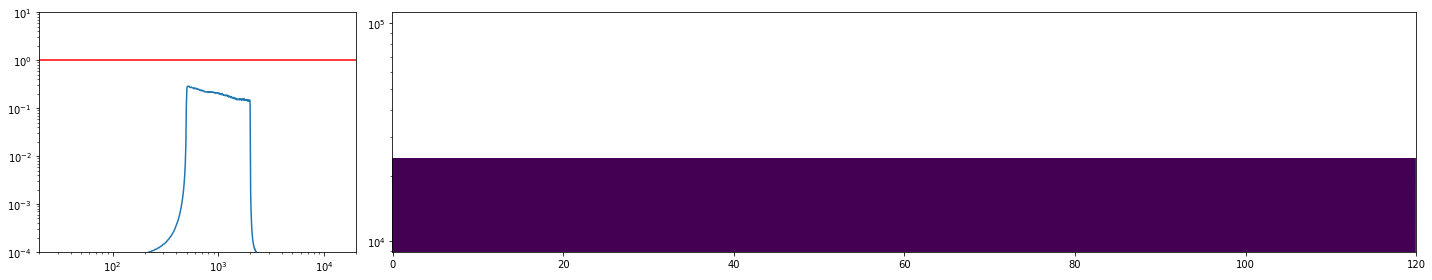

D:/Music/audiocheck.net_pinknoise.flac
Sound(duration=0:00:10.000023, channels=1, dtype=float32) 0.7581024169921875
dE/df peak: 6.6755771117709415, dE/dlog f peak: 0.7077620162682337
(108, 4097)


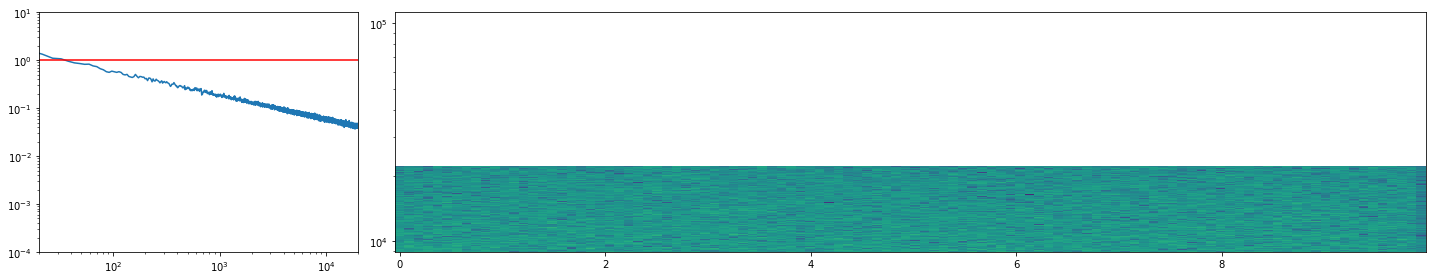

D:/Music/ref_pink.flac
Sound(duration=0:00:05, channels=1, dtype=float32) 0.2820892333984375
dE/df peak: 0.748940330647037, dE/dlog f peak: 0.1420958569060886
(54, 4097)


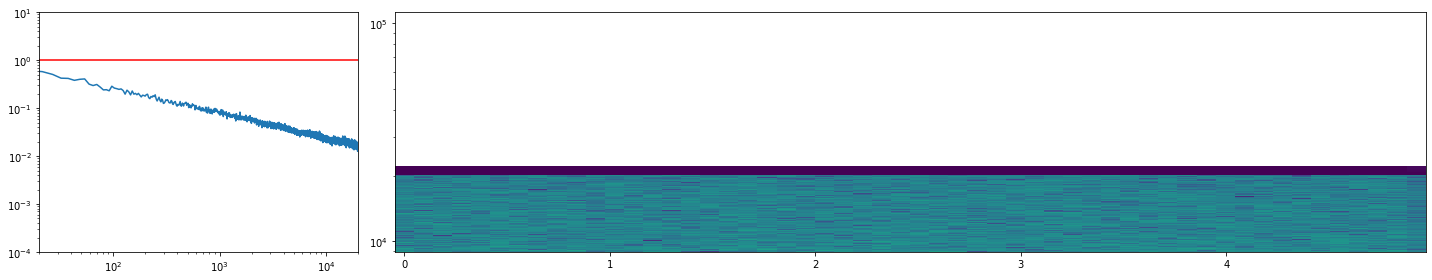

D:/Music/TEST_White noise (ID 1037)_BSB.flac
Sound(duration=0:05:00.032000, channels=1, dtype=float32) 0.9999847412109375
dE/df peak: 0.1838877727512754, dE/dlog f peak: 13.400798505568105
(3516, 4097)


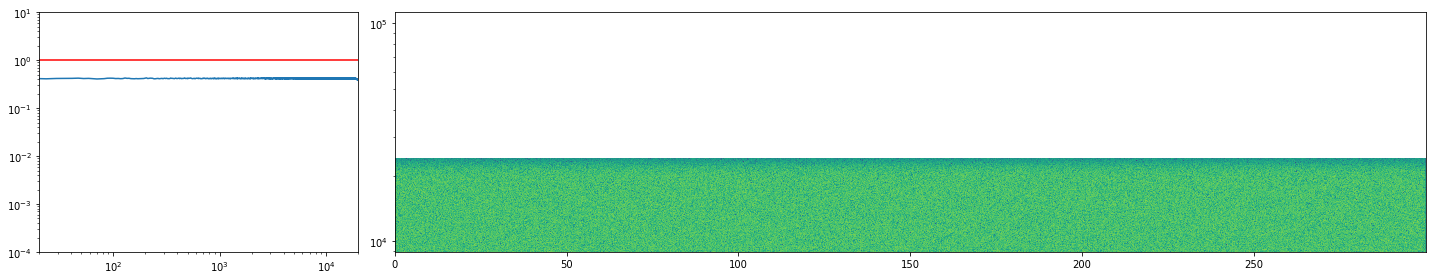

D:/Music/audiocheck.net_whitenoise.flac
Sound(duration=0:00:10.000023, channels=1, dtype=float32) 0.501190185546875
dE/df peak: 0.05742275682616416, dE/dlog f peak: 3.29357755996125
(108, 4097)


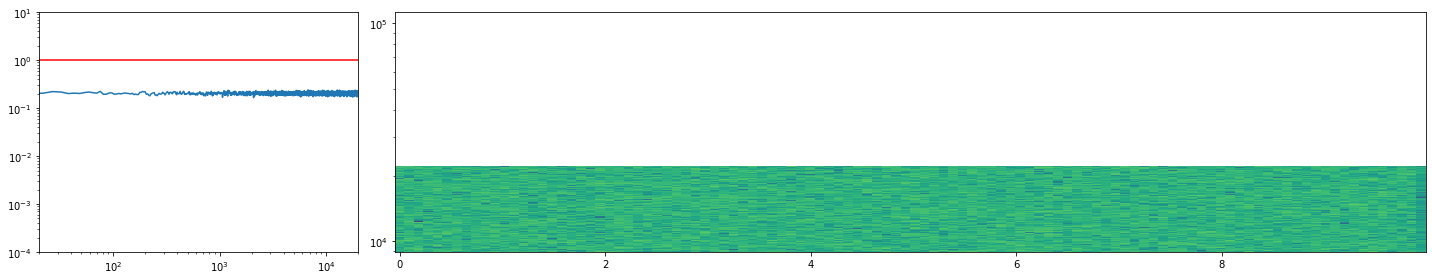

D:/Music/audiocheck.net_whitenoisegaussian.flac
Sound(duration=0:00:10.000023, channels=1, dtype=float32) 0.9999847412109375
dE/df peak: 0.0589159520997799, dE/dlog f peak: 3.240811951828249
(108, 4097)


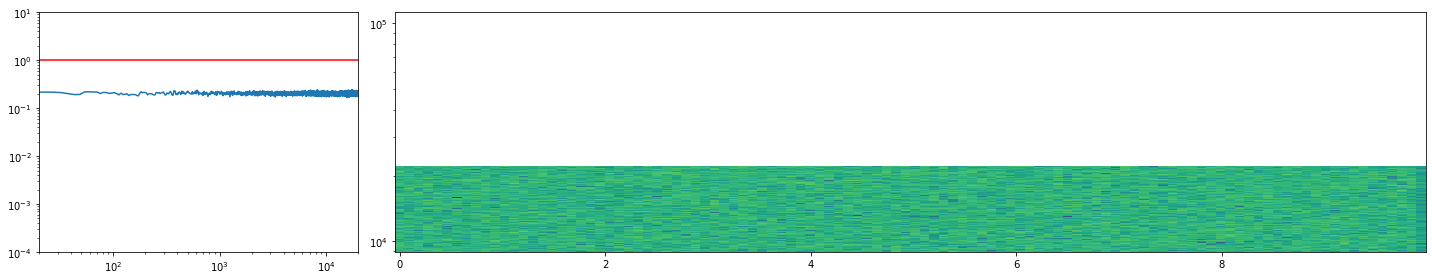

D:/Music/Albums/Imagine Dragons/2017. Evolve/03. Believer.flac
Sound(duration=0:03:24.346667, channels=2, dtype=float32) 0.9988250732421875
dE/df peak: 17.93850899386001, dE/dlog f peak: 152.42240544939617
(2201, 4097)


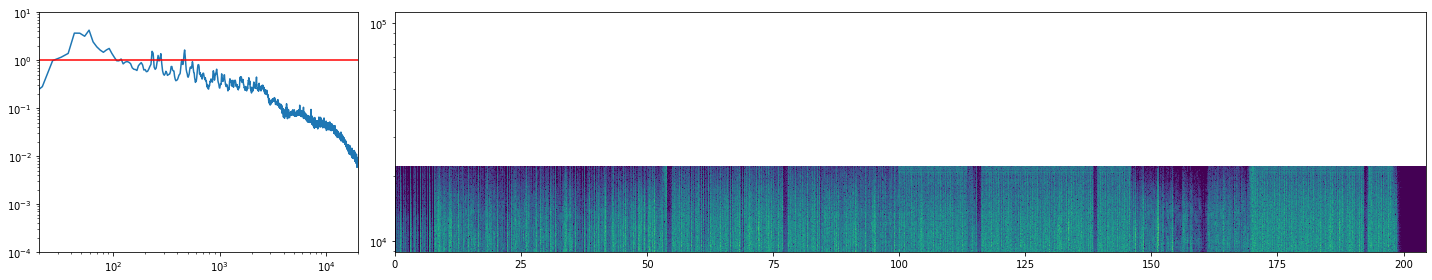

uniform
Sound(duration=0:00:05, channels=1, dtype=float32) 0.9999890327453613
dE/df peak: 0.25817587397114405, dE/dlog f peak: 12.239813677146685
(54, 4097)


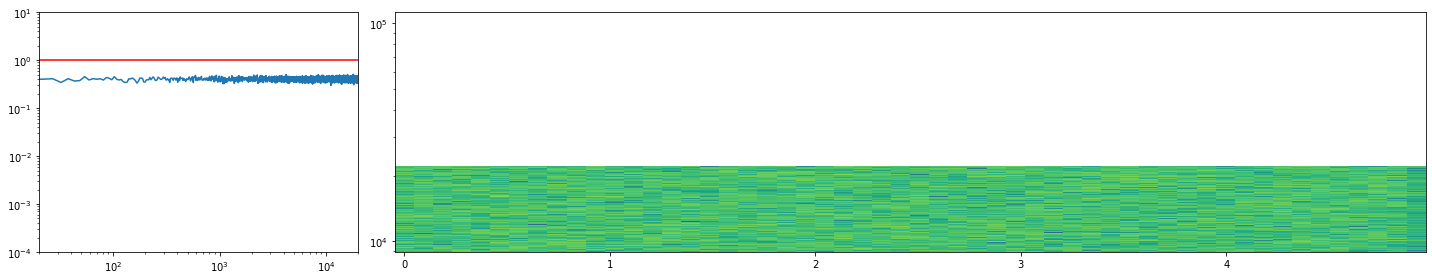

gaussian
Sound(duration=0:00:05, channels=1, dtype=float32) 1.0
dE/df peak: 0.4166153469701137, dE/dlog f peak: 21.333207880712507
(54, 4097)


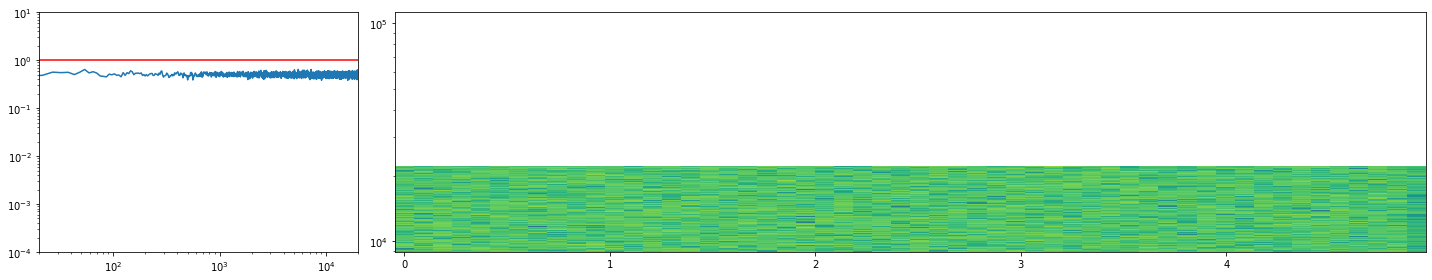

In [17]:
import matplotlib.pyplot as plt

ss = {
    p: Sound.load(p)
    for p in [
        'D:/Music/TEST_Pink noise (ID 0432)_BSB.flac',
        'D:/Music/EBU-reference_listening_signal_pinknoise_500Hz_2kHz_R128.flac',
        'D:/Music/audiocheck.net_pinknoise.flac',
        'D:/Music/ref_pink.flac',
        'D:/Music/TEST_White noise (ID 1037)_BSB.flac',
        'D:/Music/audiocheck.net_whitenoise.flac',
        'D:/Music/audiocheck.net_whitenoisegaussian.flac',
        'D:/Music/Albums/Imagine Dragons/2017. Evolve/03. Believer.flac',
    ]
}
ss |= {'uniform': uniform, 'normal': normal}

MIN_VOL = 1e-4
F0, F1 = 20, 20_000

for p, gain in ss.items():
    print(p)
    print(gain, gain.data.ptp() / 2)

    wstep, gain, tf, t_logf, q, q2 = spectrum(gain, wsize=8192, f0=F0, f1=F1)
    print(f'dE/df peak: {gain.max()}, dE/dlog f peak: {t_logf.max()}')

    fig = plt.figure(figsize=(20, 4))
    gs = fig.add_gridspec(1, 4)
    ax = [fig.add_subplot(gs[:, 0]), fig.add_subplot(gs[:, 1:])]

    ax[0].plot(q, gain**0.5)
    ax[0].axhline(1, color='red')
    ax[0].set(xscale='log', yscale='log', xlim=(F0, F1), ylim=(MIN_VOL, 10))

    print(tf.shape)
    ax[1].pcolormesh(
        np.arange(tf.shape[0]) * wstep / gain.rate,
        q,
        np.log10(np.maximum(tf.T, MIN_VOL**2)) / 2,
        vmin=np.log10(MIN_VOL),
        vmax=1,
    )
    # ax[1].pcolormesh(np.arange(t_logf.shape[0]) * wstep / s.rate,
    #                  q2,
    #                  np.log10(np.maximum(t_logf.T, MIN_VOL ** 2)) / 2,
    #                  vmin=np.log10(MIN_VOL),
    #                  vmax=1)
    ax[1].set(yscale='log')

    fig.tight_layout()
    plt.show()